In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, glob, os
import scipy.stats as stats, scipy.io as sio
from scipy.ndimage import gaussian_filter1d

### Objective
0. Run after neur3.ipynb
1. Visualize trial contrasted PSTH
2. Encoding analyses

In [2]:
patient = 18

### load data saved by neur3.ipynb

In [3]:
processed_data_dir = f'../../results/2025{patient}/records/processed_data'

# load all dfs
df_spikes = pd.read_parquet(f'{processed_data_dir}/df_spikes.parquet')
df_trigs  = pd.read_parquet(f'{processed_data_dir}/df_trigs.parquet')
df_psychopy_all = pd.read_csv('../../results/psychopy/all_subjs_clean.csv')
df_psychopy  = df_psychopy_all.loc[df_psychopy_all['subj'] == patient].reset_index(drop=True)

# load 2d spike and 3d FR arrays for all epochs
epochs = ['baseline', 'stim', 'delay', 'response', 'feedback']
all_spikes, all_FRs, all_bin_centers = {}, {}, {}
for epoch in epochs:
    all_spikes[epoch]      = np.load(f'{processed_data_dir}/{epoch}_spikes.npy', allow_pickle=True)
    all_FRs[epoch]         = np.load(f'{processed_data_dir}/{epoch}_FRs.npy')
    all_bin_centers[epoch] = np.load(f'{processed_data_dir}/{epoch}_bin_centers.npy')
base_FRs = all_FRs['baseline']
n_neurs, n_trials = df_spikes.shape

print(f'{n_neurs} neurons, {len(df_psychopy)} trials for patient {patient}')

23 neurons, 240 trials for patient 18


### helpers

In [4]:
def get_normed_FRs(FRs, base_FRs):
    return FRs - base_FRs.mean(axis=(0, 2), keepdims=True)


def get_contrast_in_epoch(df_psychopy, contrast):
    ''' split pre-loaded epoch arrays by contrast — just index slicing, no recomputation '''

    cont_trials, cont_labels = [], []

    if contrast == 'valence':
        cont_trials.append(df_psychopy[df_psychopy['stim_pos_aligned'] > df_psychopy['div_pos_aligned']].index)
        cont_trials.append(df_psychopy[df_psychopy['stim_pos_aligned'] < df_psychopy['div_pos_aligned']].index)
        cont_labels += ['gain', 'loss']
    elif contrast == 'ambiguity':
        cont_trials.append(df_psychopy[~df_psychopy['uncertainty']].index)
        cont_trials.append(df_psychopy[df_psychopy['uncertainty']].index)
        cont_labels += ['certain', 'uncertain']
    elif contrast == 'resp_dir':
        cont_trials.append(df_psychopy[df_psychopy['chosen_pos'] > df_psychopy['div_pos']].index)
        cont_trials.append(df_psychopy[df_psychopy['chosen_pos'] < df_psychopy['div_pos']].index)
        cont_labels += ['right', 'left']
    elif contrast == 'normed_RT':
        median_rt = df_psychopy['normed_RT'].median()
        cont_trials.append(df_psychopy[df_psychopy['normed_RT'] <= median_rt].index)
        cont_trials.append(df_psychopy[df_psychopy['normed_RT'] > median_rt].index)
        cont_labels += ['fast', 'slow']
    elif contrast == 'outcome': # feedback
        for val, label in zip([3, 1, -1, -3], ['3 coins', '1 coin', '-1 coin', '-3 coins']):
            cont_trials.append(df_psychopy[df_psychopy['outcome'] == val].index)
            cont_labels.append(label)
    elif contrast == 'boundary_context':
        for cond in ['curv_comp', 'baseline', 'flat_comp']:
            cont_trials.append(df_psychopy[df_psychopy['condition'] == cond].index)
            cont_labels.append(cond)
    elif contrast == 'baseline vs compressed conditions':
        cont_trials.append(df_psychopy[df_psychopy['condition'] != 'baseline'].index)
        cont_trials.append(df_psychopy[df_psychopy['condition'] == 'baseline'].index)
        cont_labels += ['comp', 'base']
    else:
        raise ValueError(f'Invalid contrast: {contrast}')

    print(f'contrast: {contrast} | #trials per group should be ~240/#contrasts')
    return cont_trials, cont_labels

### all neurons — contrasted rasters + PSTHs

contrast: boundary_context | #trials per group should be ~240/#contrasts


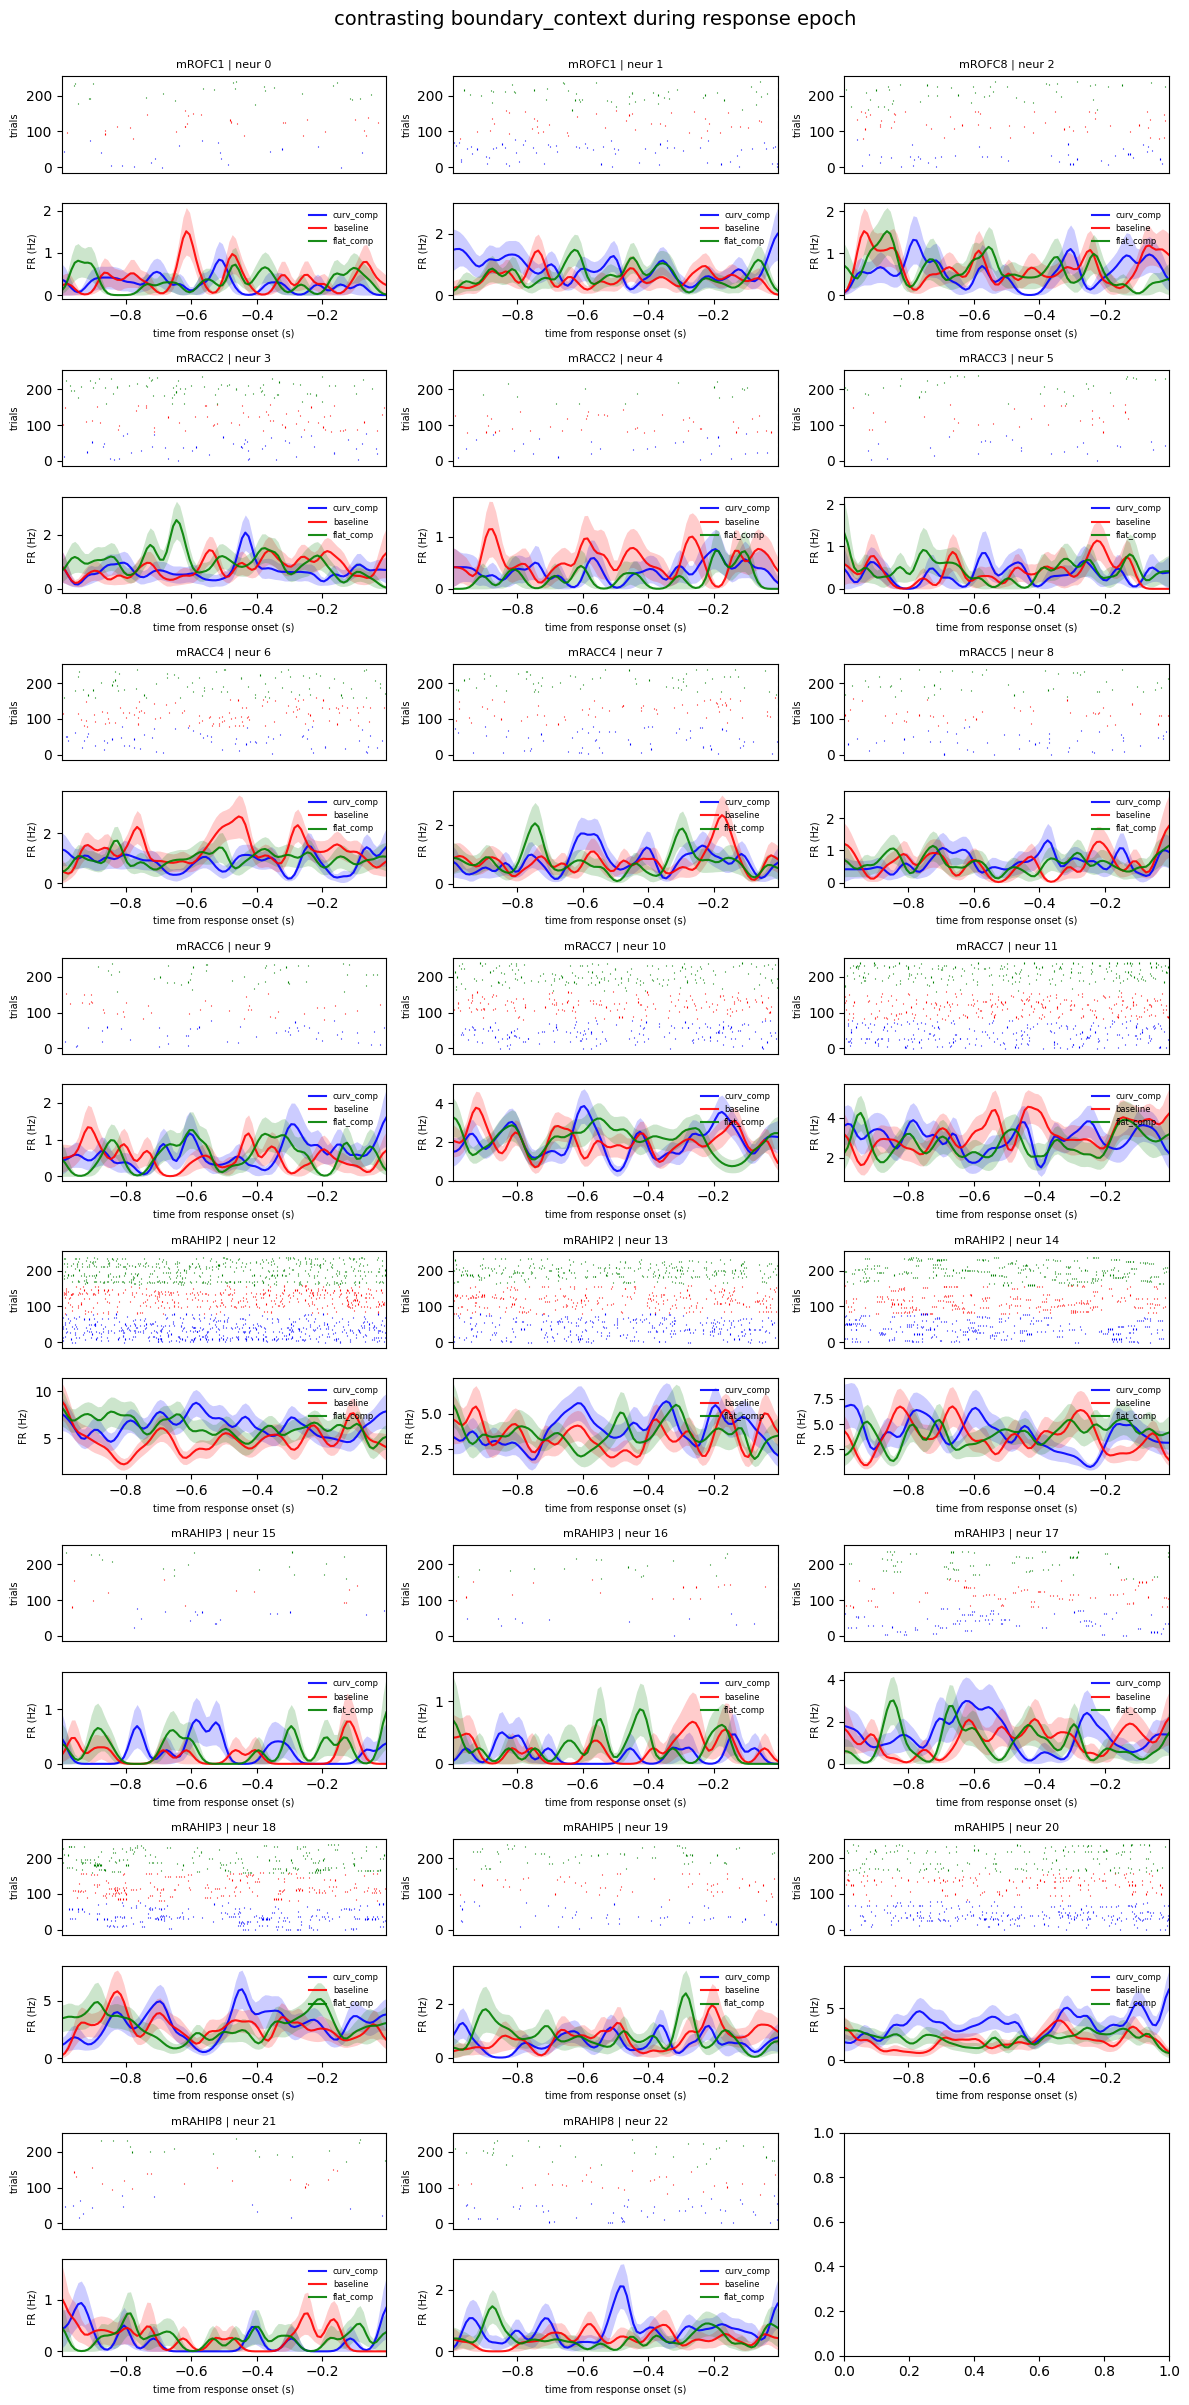

In [5]:
norm, epoch, contrast = False, 'response', 'boundary_context'
spikes      = all_spikes[epoch]
FRs         = all_FRs[epoch]
bin_centers = all_bin_centers[epoch]

cont_trials, cont_labels = get_contrast_in_epoch(df_psychopy, contrast)

if norm: normed_FRs, yaxis_lab = get_normed_FRs(FRs, base_FRs), 'norm. '
else: normed_FRs, yaxis_lab = FRs.copy(), ''

n_trials, n_neurs, _ = FRs.shape
colors = ['b', 'r', 'g', 'k']

n_cols = 3
n_rows = int(np.ceil(n_neurs / n_cols))
fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*3))
axs = axs.flatten()

ax_idx = 0
for neur_id in range(n_neurs):
    if ax_idx >= len(axs):
        break

    ax_main = axs[ax_idx]
    ss = ax_main.get_subplotspec()
    ax_main.remove()

    gs = ss.subgridspec(2, 1, height_ratios=[1, 1])
    ax_raster = fig.add_subplot(gs[0])
    ax_psth   = fig.add_subplot(gs[1], sharex=ax_raster)

    # raster
    raster_trial_list, color_trial_list = [], []
    for idx in range(len(cont_labels)):
        raster_trial_list.extend(list(spikes[cont_trials[idx], neur_id]))
        color_trial_list.extend([colors[idx]] * len(cont_trials[idx]))

    ax_raster.axvline(0, color='k', linestyle='--', alpha=0.5)
    ax_raster.eventplot(raster_trial_list, orientation='horizontal', colors=color_trial_list, linewidths=0.8, linelengths=3.0)
    ax_raster.set_title(f"{df_spikes['region'].iloc[neur_id]} | neur {neur_id}", fontsize=8)
    ax_raster.set_ylabel('trials', fontsize=7)
    ax_raster.tick_params(axis='x', which='both', bottom=False, labelbottom=False)

    # psth
    for idx in range(len(cont_labels)):
        cont_data = normed_FRs[cont_trials[idx], neur_id, :]
        mu = cont_data.mean(axis=0)
        sderr = (cont_data.std(axis=0, ddof=1) / np.sqrt(cont_data.shape[0])
                 if cont_data.shape[0] > 1 else np.zeros_like(mu))
        ax_psth.plot(bin_centers, mu, color=colors[idx], alpha=0.9, label=cont_labels[idx])
        ax_psth.fill_between(bin_centers, mu - sderr, mu + sderr, color=colors[idx], alpha=0.2, linewidth=0)

    ax_psth.axvline(0, color='k', linestyle='--', alpha=0.5)
    ax_psth.set_xlim(bin_centers[0], bin_centers[-1])
    ax_psth.set_ylabel(f'{yaxis_lab}FR (Hz)', fontsize=7)
    ax_psth.set_xlabel(f'time from {epoch} onset (s)', fontsize=7)
    ax_psth.legend(loc='upper right', fontsize=6, frameon=False)

    ax_idx += 1

plt.suptitle(f'contrasting {contrast} during {epoch} epoch', y=1.0, fontsize=14)
plt.tight_layout()
plt.show()

### single neuron

In [8]:
# reg = 'mLACC5'
# neur_id = df_spikes[df_spikes['region'] == reg].index[0]
# colors = ['b', 'r', 'g', 'k']

# fig, axs = plt.subplots(2, 1, figsize=(4, 6), sharex=True)

# # raster
# raster_trial_list, color_trial_list = [], []
# for indx in [1, 0]:
#     cont_label, cont_trial, cont_color = cont_labels[indx], cont_trials[indx], colors[indx]
#     raster_trial_list.extend(list(spikes[cont_trial, neur_id]))
#     color_trial_list.extend([cont_color] * len(cont_trial))

# axs[0].axvline(0, color='k', linestyle='--', alpha=0.5)
# axs[0].eventplot(raster_trial_list, orientation='horizontal', colors=color_trial_list, linewidths=1.0, linelengths=3.0)
# axs[0].set_ylabel('sorted trials')

# # psth
# for indx in range(len(cont_labels)):
#     cont_label, cont_trial, cont_color = cont_labels[indx], cont_trials[indx], colors[indx]
#     data = normed_FRs[cont_trial, neur_id, :]
#     mu = data.mean(axis=0)
#     sderr = (data.std(axis=0, ddof=1) / np.sqrt(data.shape[0])) if data.shape[0] > 1 else np.zeros_like(mu)
#     axs[1].plot(bin_centers, mu, color=cont_color, alpha=0.9, label=cont_label)
#     axs[1].fill_between(bin_centers, mu - sderr, mu + sderr, color=cont_color, alpha=0.2, linewidth=0)

# axs[1].axvline(0, color='k', linestyle='--', alpha=0.5)
# axs[1].set_ylabel('normed FR (Hz)')
# axs[1].set_xlabel(f'time from {epoch} onset (s)')
# axs[1].legend(loc='upper right')
# plt.tight_layout()
# plt.show()